In [45]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [46]:
df = pd.read_csv("dataset/df_final_agritech.csv")
df.shape

(64368, 24)

### EDA data engineering

In [47]:
# supression de tous les item sans yield
df = df.loc[~(df['Value'].isna()),:]
df.shape

(55141, 24)

In [48]:
# supression de la colonne Year pour passer en données non temporelles :
del_column = ['Year']
df = df.drop(columns=del_column)
df.shape

(55141, 23)

In [49]:
# supression de la colonne Element qui est catégorielle et avec une seul classe -> 'Yield'
del_column = ['Element']
df = df.drop(columns=del_column)
df.shape

(55141, 22)

In [50]:
# on ne garde que les lignes avec l'unité 'kg/ha'
df = df.loc[(df['Unit']=='kg/ha'),:]

# supression de la colonne Unit qui est catégorielle et avec une seul classe -> 'kg/ha'
del_column = ['Unit']
df = df.drop(columns=del_column)
df.shape

(54235, 21)

In [51]:
# supression des colonnes climatiques

del_column = ['cld_mean_pct', 'pre_total_mm',
       'tmp_mean_c', 'wet_days_total', 'frost_days_total', 'pet_total_mm',
       'diurnal_range_mean_c', 'tmp_max_mean_c', 'tmp_min_mean_c',
       'vap_pressure_mean_hpa']
df = df.drop(columns=del_column)
df.shape

(54235, 11)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54235 entries, 0 to 64367
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             54235 non-null  object 
 1   Item                             54235 non-null  object 
 2   Value                            54235 non-null  float64
 3   Nutrient nitrogen N (total)      54053 non-null  float64
 4   Nutrient phosphate P2O5 (total)  54053 non-null  float64
 5   Nutrient potash K2O (total)      53991 non-null  float64
 6   Fungicides and Bactericides      54235 non-null  float64
 7   Herbicides                       54235 non-null  float64
 8   Insecticides                     54235 non-null  float64
 9   Pesticides (total)               54235 non-null  float64
 10  Rodenticides                     47200 non-null  float64
dtypes: float64(9), object(2)
memory usage: 5.0+ MB


In [53]:
# gestion des valeurs manquantes pour les colonnes numériques 


# groupe qui a moins de 0.5% de valeurs manquantes -> imputation par la valeur médiane
cols_nutrients = [
    'Nutrient nitrogen N (total)',
    'Nutrient phosphate P2O5 (total)',
    'Nutrient potash K2O (total)'
]
df[cols_nutrients] = SimpleImputer(strategy='median').fit_transform(df[cols_nutrients])

# Rodenticides avec 13% de valeurs manquantes 
# on considère que c'est une absence d'utilisation donc on force à 0
df[['Rodenticides']] = SimpleImputer(strategy='constant', fill_value=0).fit_transform(df[['Rodenticides']])

### Suppression des Items qui sont des regroupements de plusieurs cultures , donc celles contenant les libellés ['primary','total','other']

In [54]:

#Suppression des Items qui sont des groupes , donc celles contenant les libellés ['primary','total','other']
item_importance = df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)
print(len(item_importance))
df_propre = df_propre[
    ~df_propre['Item'].str.contains('primary', case=False, na=False) 
    & ~df_propre['Item'].str.contains('total', case=False, na=False)
    & ~df_propre['Item'].str.contains('other', case=False, na=False)
    ]
df_propre.shape
item_importance = df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)
print(len(item_importance))

60
60


### Supression des outliers par la méthode de l'IQR (Tukey), quantile

In [55]:
Q1 = df_propre['Value'].quantile(0.25)
Q3 = df_propre['Value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_propre = df_propre[(df_propre['Value'] >= lower) & (df_propre['Value'] <= upper)]
df_propre.shape


(28256, 11)

### section épurer les Items, maximum 60 Items

In [56]:
# on groupe chaque item par leur nombre d'occurences 
item_importance = df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)

#on garde les 60 premières Items 
filtre_item = item_importance.head(60).index
df_propre = df_propre.loc[df_propre['Item'].isin(filtre_item), :]
df_propre.shape

print(len(item_importance))
print(len(df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)))

60
60


In [57]:
df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)

Item
Barley                                                          879
Wheat                                                           870
Oats                                                            852
Rye                                                             846
Peas, green                                                     813
Rape or colza seed                                              786
Peas, dry                                                       777
Plums and sloes                                                 721
Oilcrops, Oil Equivalent                                        720
Cherries                                                        699
Raspberries                                                     693
Oilcrops, Cake Equivalent                                       684
Maize (corn)                                                    680
Triticale                                                       637
Grapes                                     

### EDA graphique

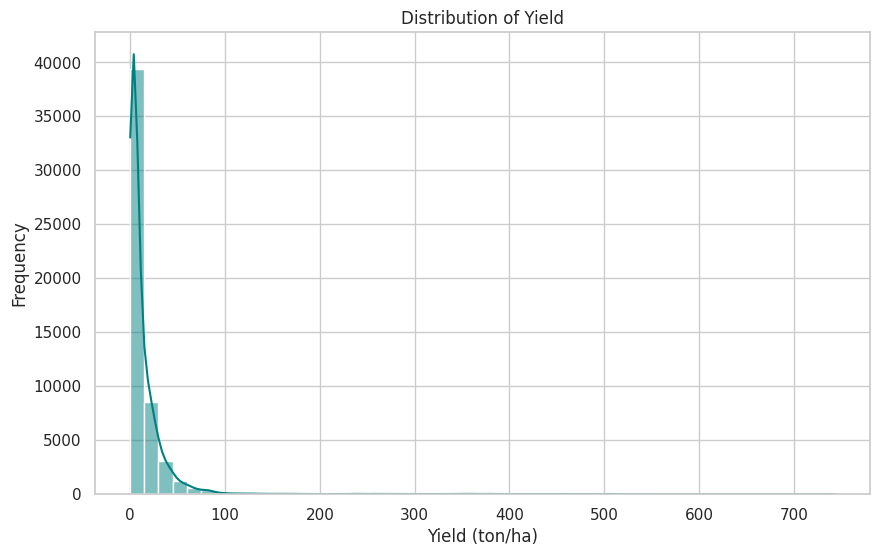

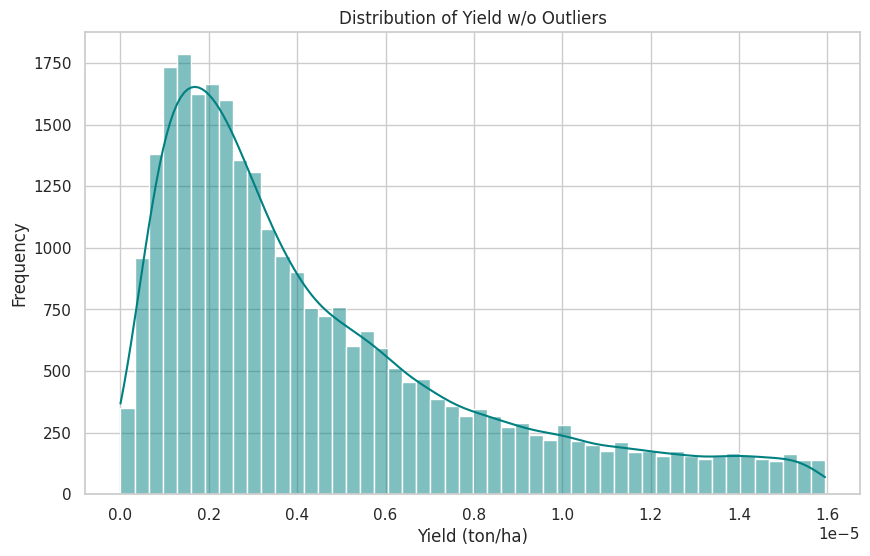

In [58]:
df_outliers =  df_propre
# Changement d'unité => kg/ha --> ton/ha
df["Value"] = df["Value"] / 1000

# Histogramme de 'Value'
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(df["Value"], bins=50, kde=True, color='teal')
plt.title("Distribution of Yield")
plt.xlabel("Yield (ton/ha)")
plt.ylabel("Frequency")
plt.show()


# Changement d'unité => kg/ha --> ton/ha
df_outliers["Value"] = df_outliers["Value"] / 1000

# Histogramme de 'Value'
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(df_outliers["Value"], bins=50, kde=True, color='teal')
plt.title("Distribution of Yield w/o Outliers")
plt.xlabel("Yield (ton/ha)")
plt.ylabel("Frequency")
plt.show()

In [59]:
# Corrélation avec la cible (colonne 'value')

corr_numeric = df_propre.corr(numeric_only=True)
corr_numeric.loc[:,['Value']].sort_values(by=['Value'], ascending=False)


,Value
Value,1.000000
Herbicides,0.021706
Pesticides (total),0.019323
Nutrient nitrogen N (total),0.018248
Fungicides and Bactericides,0.015371
Insecticides,0.015365
Rodenticides,0.011126
Nutrient phosphate P2O5 (total),-0.004341
Nutrient potash K2O (total),-0.015488


In [60]:
numeric_feature = [x for x in df_propre.columns if df_propre.dtypes[x] == "float64"]
categorc_feature = [x for x in df_propre.columns if df_propre.dtypes[x] != "float64"]
print(numeric_feature)
print(categorc_feature)


['Value', 'Nutrient nitrogen N (total)', 'Nutrient phosphate P2O5 (total)', 'Nutrient potash K2O (total)', 'Fungicides and Bactericides', 'Herbicides', 'Insecticides', 'Pesticides (total)', 'Rodenticides']
['Area', 'Item']


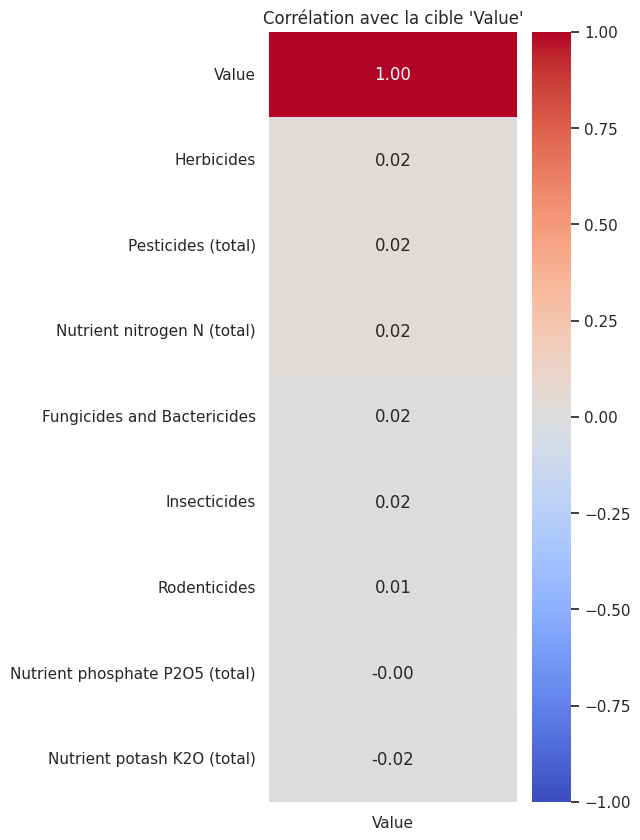

In [61]:
# 1. Calcul de la corrélation par rapport à 'valeur' uniquement
corr_cible = df_propre.corr(numeric_only=True)[['Value']].sort_values(by='Value', ascending=False)

# 2. Affichage d'une heatmap en bande verticale
plt.figure(figsize=(4, 10))
sns.heatmap(corr_cible, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Corrélation avec la cible 'Value'")
plt.show()

In [62]:
chemin_export = "dataset/df_EDA_agritech.csv"

# Export en CSV
df_propre.to_csv(chemin_export, index=False, encoding='utf-8')